# Main Wave-Diffusion Inference script
This is the main script used to create samples using the direct Wave-Diffusion
### Imports

In [ ]:
#Set Dir 
import sys, os
sys.path.append(os.path.abspath('..'))

# Torch
import torch
from torch import nn, Tensor
import torch.optim as optim

# Utils
import numpy as np
import logging
import matplotlib.pyplot as plt


# Base Scripts
from Libraries.Utils import *
from Libraries.U_Net import *
from Libraries.Diffusion import *

### Imports for Visualizing

In [29]:
from torchviz import make_dot
from torch.utils.tensorboard import SummaryWriter
import tensorboard
from tensorboard import notebook
from torchinfo import summary

## Setup

### Logging

In [5]:
logging_level: int = logging.INFO #LIGHT_DEBUG
logging.basicConfig(level=logging_level, format='%(asctime)s - %(levelname)s - %(message)s')
logger: logging.Logger = logging.getLogger(__name__)

### Initial Setup

In [4]:
remote_kernel: bool = True
device: str = "cuda" if torch.cuda.is_available() else "cpu"
test_data_name: str = "../Data/unseen_test_data.npy"
model_name: str = "WaveDiffusion_v6"
full_model_path: str = OS().path_to_remote_path("../Models/{}.pth".format(model_name), remote_kernel)

### Hyperparameters

In [6]:
batch_size: int = 16
seq_length: int = 2**17
train_v_obj: bool = True

### Data loading

In [ ]:
md = ModelData()
md.load_data_from_path(data_path=OS().path_to_remote_path(test_data_name, remote_kernel))
md.create_validation_split()
test_dataset, _ = md.create_datasets()
test_dataloader, _ = md.create_dataloaders(batch_size, num_workers=1)
logger.info(f"Created test dataset with length {len(md.train_dataset)}")

2025-09-03 13:29:33,179 - INFO - Created test dataset with length 268


## Model Setup

In [7]:
u_net = UNet(in_channels=1, n_layers=4, base_channels=48, embed_dim=128, timesteps=1000, v_obj_sampler=True, kernel_size=11).to(device)

### Optimizers & Schedulers

### Load Model

In [ ]:
if os.path.exists(full_model_path):
    model = torch.load(full_model_path, map_location=device)
    u_net.load_state_dict(model["u_net"])
    logger.info(f"Model {model_name} loaded with {TrainingUtils().count_parameters(u_net)} Parameters")
else: 
    logger.info(f"Model {model_name} could not be loaded")

2025-09-03 13:29:37,693 - INFO - Model WaveDiffusion_v6 loaded with ~47.93M Parameters


## Diffusion Class Setup

In [ ]:
torch.backends.cudnn.benchmark = True
diffusion = Diffusion(noise_steps=1000, schedule="linear", inp_shape=[batch_size, 1, seq_length], device=device)

## Inference

2025-09-03 12:57:56,086 - INFO - Started sampling 16 samples on cuda
2025-09-03 13:06:57,391 - INFO - Created 16 samples


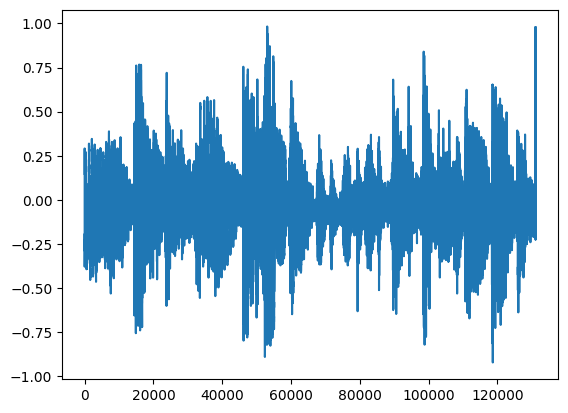

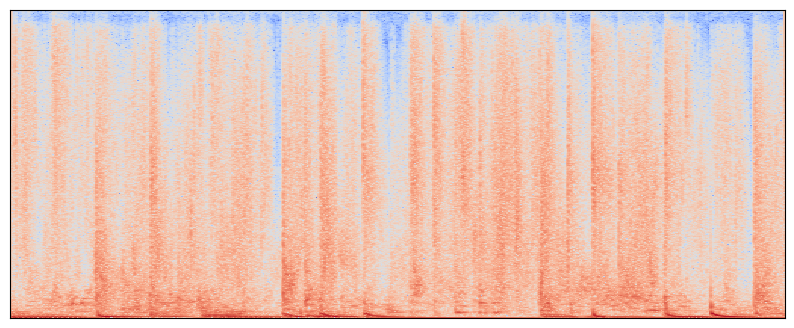

In [ ]:
idx = 0
n_steps = 1000
if not train_v_obj:
    out = diffusion.bwd_diffusion_ddim(u_net, [batch_size, 1, seq_length], n_steps=n_steps, eta=0)
else:
    if diffusion.fb:
        out, x = diffusion.bwd_diffusion_v_obj(u_net, [batch_size // 2, 1, seq_length], n_steps=n_steps)
    else:
        out = diffusion.bwd_diffusion_v_obj(u_net, [batch_size // 2, 1, seq_length], n_steps=n_steps)

out = np.clip(out, -1, 1)
ad = AudioData(out[idx][0])
ad.save_audio_file(f"Results/{model_name}_test_sample{idx}_s{n_steps}.wav")
TrainingUtils().visualize_audio_and_spect(out[idx][0])


## Save Model Architecture

### Torchviz

In [ ]:
x, t = torch.randn(1, 1, seq_length), torch.randn(1)
y = u_net(x, t)
make_dot(y, params=dict(u_net.named_parameters())).render(OS().path_to_remote_path(f"../Results/{model_name}", remote_kernel), format="png")

'WaveDiffusion_v6.png'

### Tensorboard

In [ ]:
x, t = torch.randn(1, 1, seq_length), torch.randn(1)
writer = SummaryWriter(OS().path_to_remote_path(f'../Results/runs/{model_name}', remote_kernel))
writer.add_graph(u_net, [x,t])
writer.close()

In [18]:
notebook.start("--logdir=runs")

Reusing TensorBoard on port 6007 (pid 352), started 0:00:41 ago. (Use '!kill 352' to kill it.)

### Summarywriter

In [30]:
summary(u_net, input_size=[(12, 1, seq_length), (12, 1)], device=device)

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [12, 1, 131072]           --
├─Sequential: 1-1                        [12, 128]                 --
│    └─Linear: 2-1                       [12, 128]                 16,512
│    └─SiLU: 2-2                         [12, 128]                 --
│    └─Linear: 2-3                       [12, 128]                 16,512
├─ModuleList: 1-2                        --                        --
│    └─Conv1d: 2-4                       [12, 48, 131072]          576
│    └─ResBlock: 2-5                     [12, 48, 131072]          --
│    │    └─Linear: 3-1                  [12, 48]                  6,192
│    │    └─BatchNorm1d: 3-2             [12, 48, 131072]          96
│    │    └─SiLU: 3-3                    [12, 48, 131072]          --
│    │    └─Conv1d: 3-4                  [12, 48, 131072]          25,392
│    │    └─SiLU: 3-5                    [12, 48, 131072]          --